In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from tqdm.auto import tqdm
import pyro
import pyro.distributions as dist
from torch.distributions import constraints
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam
import math




# Установка случайного сида для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../data/data.csv')
df

,"Sigma, Mpa",T.K,t.h,Th,C,Cr,Co,Mo,W,Al,...,La,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni
0,241.316495,1144.2600,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,NaN,99.500
1,241.316495,1144.2600,113.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.75,NaN,NaN,NaN,99.250
2,241.316495,1144.2600,68.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.05,99.450
3,241.316495,1144.2600,40.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.20,99.300
4,241.316495,1144.2600,32.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.50,99.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,1061.792578,922.0389,1183.7,NaN,0.02,17.0,28.4,3.4,1.9,1.03,...,NaN,6.0,0.05,0.05,NaN,NaN,0.02,NaN,NaN,33.904
3442,1103.161120,866.4833,25554.7,NaN,0.02,17.0,28.4,3.4,1.9,1.03,...,NaN,6.0,0.05,0.05,NaN,NaN,0.02,NaN,NaN,33.904
3443,241.316495,1199.8170,183.2,NaN,0.18,10.0,15.0,3.0,NaN,5.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.750
3444,241.316495,1199.8170,153.0,NaN,0.18,10.0,15.0,3.0,NaN,5.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.750


In [4]:
mass = '232,03806	12,011	51,9961	58,933194	95,95	183,84	26,9815385	47,867	92,90637	10,81	55,845	88,90584	91,224	180,94788	186,207	101,07	50,9415	140,116	138,90547	32,06	28,085	54,938044	24,305	30,973761998	178,49	107,8682	63,546	208,9804	207,2	192,22	72,63	69,723	58,6934'.replace(',', '.').split()
element = 'Th	C	Cr	Co	Mo	W	Al	Ti	Nb	B	Fe	Y	Zr	Ta	Re	Ru	V	Ce	La	S	Si	Mn	Mg	P	Hf	Ag	Cu	Bi	Pb	Ir	Ge	Ga	Ni'.split()
atom_mass = dict(zip(element, mass))

In [5]:
atom_mass['Ni']

'58.6934'

In [6]:
for elem in df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list():
    df[elem] = df[elem] / float(atom_mass[elem])
df['sum'] = df[df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list()].sum(axis=1, skipna=True)
df['PLM'] = df['T.K'] * (20 + np.log10(df['t.h'])) * 1e-5

cols = df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns
df.loc[:, cols] = df.loc[:, cols].div(df['sum'], axis=0)
df.loc[:, cols] = df.loc[:, cols].div(df['Ni'], axis=0)



df = df.fillna(0)

df = df.drop(columns=['T.K', 't.h', 'Ni', 'sum'])

df

,"Sigma, Mpa",Th,C,Cr,Co,Mo,W,Al,Ti,Nb,...,La,S,Si,Mn,P,Hf,Cu,Ge,Ga,PLM
0,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001652,0.000000,0.0,0.000000,0.139405
1,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.002485,0.000000,0.0,0.000000,0.149239
2,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001653,0.000000,0.0,0.000423,0.147465
3,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001656,0.000000,0.0,0.001695,0.146154
4,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001661,0.000000,0.0,0.004252,0.145925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,1061.792578,0.0,0.002883,0.566000,0.834251,0.061344,0.017892,0.066086,0.112115,0.020497,...,0.0,0.323986,0.003082,0.001576,0.0,0.000000,0.000545,0.0,0.000000,0.368295
3442,1103.161120,0.0,0.002883,0.566000,0.834251,0.061344,0.017892,0.066086,0.112115,0.020497,...,0.0,0.323986,0.003082,0.001576,0.0,0.000000,0.000545,0.0,0.000000,0.366118
3443,241.316495,0.0,0.014721,0.188921,0.250025,0.030713,0.000000,0.200238,0.112870,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.262391
3444,241.316495,0.0,0.014721,0.188921,0.250025,0.030713,0.000000,0.200238,0.112870,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.261469


In [7]:

def log_transform_target(sigma):
    return -np.log10(sigma)

def inverse_log_transform(y):
    y = np.asarray(y, dtype=np.float64)
    return 10.0 ** (-y)

def calculate_mse(y_pred, y_true):
    """Вычисление MSE (Mean Squared Error)"""
    return torch.mean((y_pred - y_true) ** 2).item()

def calculate_rmse_absolute(sigma_pred, sigma_real):
    """
    Вычисление RMSE для физических значений σ (MPa)
    Корень из среднего квадрата абсолютных ошибок
    """
    mse = torch.mean((sigma_pred - sigma_real) ** 2).item()
    return np.sqrt(mse)

def calculate_rmse_relative(sigma_pred, sigma_real):
    """
    Вычисление RMSE согласно формуле (6) из статьи.
    Это относительная ошибка (Root Mean Square Relative Error)
    """
    epsilon = 1e-8
    relative_error = (sigma_pred - sigma_real) / (sigma_real.abs() + epsilon)
    mse_relative = torch.mean(relative_error ** 2).item()
    return np.sqrt(mse_relative)

def calculate_metrics_np(pred, real):
    eps = 1e-8
    # Абсолютная RMSE
    rmse_abs = np.sqrt(np.mean((pred - real) ** 2))
    
    # Относительная RMSE (Формула 6 из статьи)
    rel_err = (pred - real) / (real + eps)
    rmse_rel = np.sqrt(np.mean(rel_err ** 2))
    
    # MAPE
    mape = np.mean(np.abs(rel_err)) * 100
    
    # R²
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return rmse_abs, rmse_rel, mape, r2


# NN

In [1023]:
class MLPRegressorNet(nn.Module):
    """
    Обычная MLP-сеть для регрессии.
    Байесовская регуляризация будет добавлена отдельно в Pyro-модели.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim=30,
        output_dim: int = 1,
        activation: str = "tanh"
    ):
        super().__init__()

        if activation == "tanh":
            act_cls = nn.Tanh()
        elif activation == "relu":
            act_cls = nn.ReLU()
        elif activation == "silu":
            act_cls = nn.SiLU()
        elif activation == "gelu":
            act_cls = nn.GELU()
        elif activation == "elu":
            act_cls = nn.ELU()
        else:
            raise ValueError(f"Unknown activation: {activation}")


        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            act_cls,
            nn.Linear(8, 8),
            act_cls,
            nn.Linear(8, 8),
            act_cls,
            nn.Linear(8, output_dim),
        )

        self.reset_parameters()

    def reset_parameters(self):
        """
        Аккуратная инициализация весов.
        Для tanh обычно хорошо работает Xavier.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# pyro

In [1024]:
def make_map_brann_pyro_model(
    net: nn.Module,
    alpha_init: float = 0.1,
    beta_init: float = 20.0,
    alpha_prior_shape: float = 1.0,
    alpha_prior_rate: float = 10.0,
    beta_prior_shape: float = 2.0,
    beta_prior_rate: float = 0.1,
    regularize_bias: bool = True,
):
    """
    Возвращает Pyro model для MAP-BRANN.
    net:torch.nn.Module, например MLPRegressorNet.
    alpha: precision весов. Чем больше alpha, тем сильнее регуляризация.
    beta: precision шума. Чем больше beta, тем меньше шум.
    """

    def model(X, y=None):
        # Регистрируем torch.nn.Module внутри Pyro
        pyro.module("net", net)

        device = X.device
        dtype = X.dtype

        zero = torch.tensor(0.0, device=device, dtype=dtype)

        # alpha — precision весов
        alpha = pyro.param(
            "alpha",
            torch.tensor(alpha_init, device=device, dtype=dtype),
            constraint=constraints.positive
        )

        # beta — precision шума наблюдений
        beta = pyro.param(
            "beta",
            torch.tensor(beta_init, device=device, dtype=dtype),
            constraint=constraints.positive
        )

        sigma_w = torch.rsqrt(alpha)
        sigma_y = torch.rsqrt(beta)

        # Предсказание сети
        mu = net(X)

        pyro.deterministic("mu", mu)

        # Prior на веса:
        # w ~ Normal(0, alpha^{-1})
        # weight_log_prior = zero

        # for param in net.parameters():
        #     weight_log_prior = weight_log_prior + dist.Normal(
        #         zero,
        #         sigma_w
        #     ).log_prob(param).sum()

        # pyro.factor("weight_prior", weight_log_prior)

        param_log_prior = zero

        for name, param in net.named_parameters():
            is_weight = "weight" in name
            is_bias = "bias" in name

            if is_weight or (regularize_bias and is_bias):
                param_log_prior = param_log_prior + dist.Normal(
                    zero,
                    sigma_w
                ).log_prob(param).sum()

        pyro.factor("param_prior", param_log_prior)

        # Prior на alpha
        alpha_prior = dist.Gamma(
            torch.tensor(alpha_prior_shape, device=device, dtype=dtype),
            torch.tensor(alpha_prior_rate, device=device, dtype=dtype),
        )

        pyro.factor(
            "alpha_prior",
            alpha_prior.log_prob(alpha)
        )

        # Prior на beta
        beta_prior = dist.Gamma(
            torch.tensor(beta_prior_shape, device=device, dtype=dtype),
            torch.tensor(beta_prior_rate, device=device, dtype=dtype),
        )

        pyro.factor(
            "beta_prior",
            beta_prior.log_prob(beta)
        )

        # Likelihood
        with pyro.plate("data", X.shape[0]):
            pyro.sample("obs", dist.Normal(mu, sigma_y), obs=y)

    return model

def empty_guide(X, y=None):
    """
    MAP-оценка: скрытых случайных переменных в guide нет.
    Все веса, alpha и beta оптимизируются как параметры.
    """
    pass

# train

In [1025]:
def to_tensor(x, device="cpu"):
    if isinstance(x, torch.Tensor):
        return x.float().to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)


def train_map_brann(
    net,
    X_train,
    y_train,
    num_steps: int,
    lr: float,
    alpha_init: float,
    beta_init: float,
    alpha_prior_shape: float,
    alpha_prior_rate: float,
    beta_prior_shape: float,
    beta_prior_rate: float,
    regularize_bias: bool = True,
    clip_norm: float = 10.0,
    device: str = "cpu",
    seed: int | None = None,
):
    if seed is not None:
        pyro.set_rng_seed(seed)
        torch.manual_seed(seed)

    pyro.clear_param_store()

    X_train = to_tensor(X_train, device)
    y_train = to_tensor(y_train, device).squeeze(-1)

    net.to(device)

    model = make_map_brann_pyro_model(
        net=net,
        alpha_init=alpha_init,
        beta_init=beta_init,
        alpha_prior_shape=alpha_prior_shape,
        alpha_prior_rate=alpha_prior_rate,
        beta_prior_shape=beta_prior_shape,
        beta_prior_rate=beta_prior_rate,
        regularize_bias=regularize_bias
    )

    optimizer = ClippedAdam({
        "lr": lr,
        "clip_norm": clip_norm,
    })

    svi = SVI(
        model=model,
        guide=empty_guide,
        optim=optimizer,
        loss=Trace_ELBO()
    )

    n = X_train.shape[0]

    for step in range(num_steps):
        loss = svi.step(X_train, y_train) / n

    return net

# predict

In [1026]:
def predict_map_brann(net, X, device="cpu"):
    X = to_tensor(X, device)

    net.eval()

    with torch.no_grad():
        pred = net(X)

    return pred.detach().cpu().numpy()

In [1027]:
def regression_metrics_sigma(sigma_true, sigma_pred, eps=1e-8):
    sigma_true = np.asarray(sigma_true).ravel()
    sigma_pred = np.asarray(sigma_pred).ravel()

    if not np.isfinite(sigma_true).all():
        raise ValueError("sigma_true contains nan/inf")

    if not np.isfinite(sigma_pred).all():
        raise ValueError("sigma_pred contains nan/inf")

    denom = np.maximum(np.abs(sigma_true), eps)

    rmse_abs = np.sqrt(np.mean((sigma_pred - sigma_true) ** 2))
    mae_abs = np.mean(np.abs(sigma_pred - sigma_true))

    rmse_rel = np.sqrt(
        np.mean(((sigma_pred - sigma_true) / denom) ** 2)
    )

    mape = np.mean(
        np.abs((sigma_pred - sigma_true) / denom)
    ) * 100

    ss_res = np.sum((sigma_true - sigma_pred) ** 2)
    ss_tot = np.sum((sigma_true - np.mean(sigma_true)) ** 2)

    if ss_tot < eps:
        r2 = np.nan
    else:
        r2 = 1.0 - ss_res / ss_tot

    return {
        "rmse_abs": rmse_abs,
        "mae_abs": mae_abs,
        "rmse_rel": rmse_rel,
        "mape": mape,
        "r2": r2,
    }



def get_alpha_beta():
    return {
        "alpha": pyro.param("alpha").item(),
        "beta": pyro.param("beta").item(),
        "sigma_noise_scaled": 1.0 / math.sqrt(pyro.param("beta").item())
    }

In [1028]:
def get_map_brann_params():
    """
    Возвращает alpha, beta и sigma_noise в нормированной шкале y.
    """

    alpha = pyro.param("alpha").item()
    beta = pyro.param("beta").item()

    sigma_noise = 1.0 / math.sqrt(beta)

    return {
        "alpha": alpha,
        "beta": beta,
        "sigma_noise_scaled": sigma_noise,
    }


In [1029]:
def get_noise_std_original_scale(y_scaler):
    """
    y_scaler — твой StandardScaler для target.
    """
    beta = pyro.param("beta").item()
    sigma_noise_scaled = 1.0 / math.sqrt(beta)

    sigma_noise_original = sigma_noise_scaled * y_scaler.scale_[0]

    return sigma_noise_original


# main

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

target_col = 'Sigma, Mpa'
sigma = np.asarray(df[target_col], dtype=np.float32).reshape(-1, 1)
y = np.asarray(log_transform_target(sigma), dtype=np.float32).reshape(-1, 1).astype("float32")
X = df.copy().drop(columns=[target_col]).to_numpy().astype("float32")
print(X, y, sigma)

X_temp, X_test, y_temp, y_test, sigma_temp, sigma_test = train_test_split(
    X,
    y,
    sigma,
    test_size=0.1,
    random_state=42,
    shuffle=True
)


scaler_X = RobustScaler()
scaler_y = RobustScaler()


X_scaled = scaler_X.fit_transform(X_temp).astype("float32") # ???
y_scaled = scaler_y.fit_transform(y_temp).astype("float32").reshape(-1,1)



X_test_scaled = scaler_X.transform(X_test).astype("float32")
# y_test_scaled = scaler_y.transform(y_test).astype("float32").reshape(-1,1)

# X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.25, random_state=42)



[[0.         0.         0.         ... 0.         0.         0.13940506]
 [0.         0.         0.         ... 0.         0.         0.1492392 ]
 [0.         0.         0.         ... 0.         0.00042323 0.14746492]
 ...
 [0.         0.01472125 0.18892115 ... 0.         0.         0.2623908 ]
 [0.         0.01472125 0.18892115 ... 0.         0.         0.26146874]
 [0.         0.01472125 0.18892115 ... 0.         0.         0.2588929 ]] [[-2.3825872]
 [-2.3825872]
 [-2.3825872]
 ...
 [-2.3825872]
 [-2.3825872]
 [-2.4405792]] [[241.3165 ]
 [241.3165 ]
 [241.3165 ]
 ...
 [241.3165 ]
 [241.3165 ]
 [275.79028]]


In [ ]:
X_train_opt, X_val_opt, y_train_opt, y_val_opt, sigma_train_opt, sigma_val_opt = train_test_split(
    X_scaled,
    y_scaled,
    sigma_temp,
    test_size=0.2,
    random_state=42
)

input_dim = X_scaled.shape[1]

net = MLPRegressorNet(
    input_dim=input_dim,
    hidden_dim=13,
    output_dim=1,
    activation="relu"
)

history = train_map_brann(
    net=net,
    X_train=X_scaled,
    y_train=y_scaled,
    num_steps=2001,
    lr=0.005,
    alpha_init=0.01,
    beta_init=20.0,
    alpha_prior_shape = 1.0,
    alpha_prior_rate = 10.0,
    beta_prior_shape = 2.0,
    beta_prior_rate = 0.1,
    # print_every=500,
)

In [1031]:
y_pred_scaled = predict_map_brann(
    net=net,
    X=X_test_scaled,
)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()


In [1032]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


y_test_original = y_test.ravel()

params = get_map_brann_params()

print(params)

sigma_pred = inverse_log_transform(y_pred)


mse = mean_squared_error(y_test_original, y_pred)


mape = np.mean(np.abs((sigma_pred - sigma_test) / sigma_test)) * 100

mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


{'alpha': 6.639565944671631, 'beta': 8.648788452148438, 'sigma_noise_scaled': 0.34003401444203163}
MSE: 0.0326
MAE : 0.1269
R2  : 0.6908


In [1033]:
rmse_absolute = calculate_rmse_absolute(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))
rmse_relative = calculate_rmse_relative(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))

# MAPE (Mean Absolute Percentage Error)
mape = torch.mean(torch.abs((torch.FloatTensor(sigma_pred) - torch.FloatTensor(sigma_test)) / 
                                (torch.FloatTensor(sigma_test) + 1e-8))) * 100


# print(f"""{y_pred_scaled[:5]=},\n {y_pred[:5]=},\n
# {sigma_pred[:5]=}, \n{sigma_real_tensor[:5]=} \n{y_test_t[:5]=}\n""")
print(f"\nРезультаты:")
print(f"  RMSE (абсолютная): {rmse_absolute:.2f} MPa")
print(f"  RMSE (относительная, формула 6): {rmse_relative:.4f}")
print(f"  MAPE: {mape.item():.2f}%")
print(f"  Мин. предсказанное σ: {sigma_pred.min():.2f} MPa")
print(f"  Макс. предсказанное σ: {sigma_pred.max():.2f} MPa")
print(f"  Мин. реальный σ: {sigma_test.min():.2f} MPa")
print(f"  Макс. реальный σ: {sigma_test.max():.2f} MPa")


Результаты:
  RMSE (абсолютная): 303.15 MPa
  RMSE (относительная, формула 6): 2.0335
  MAPE: 108.11%
  Мин. предсказанное σ: 44.94 MPa
  Макс. предсказанное σ: 1282.95 MPa
  Мин. реальный σ: 31.00 MPa
  Макс. реальный σ: 1279.00 MPa


In [1034]:
# print(y_pred_scaled.min(), y_pred_scaled.max())
# print(y_pred.min(), y_pred.max())
# print(y_test.min(), y_test.max())


In [1035]:
# import seaborn as sns
# import matplotlib.pyplot as plt


# sns.histplot(y_pred, kde=True, bins=30, color='steelblue', stat='density')
# plt.title('Распределение переменной')
# plt.xlabel('Значение')
# plt.ylabel('Плотность')
# plt.grid(True, alpha=0.3)
# plt.show()

In [1036]:
eps = 100.0  # например, 50 MPa

relative_rmse_safe = np.sqrt(
    np.mean(((sigma_pred - sigma_test) / np.maximum(sigma_test, eps)) ** 2)
)

mape_safe = np.mean(
    np.abs((sigma_pred - sigma_test) / np.maximum(sigma_test, eps))
) * 100

print(f"Safe relative RMSE: {relative_rmse_safe:.4f}")
print(f"Safe MAPE         : {mape_safe:.2f}%")

Safe relative RMSE: 1.4876
Safe MAPE         : 94.09%


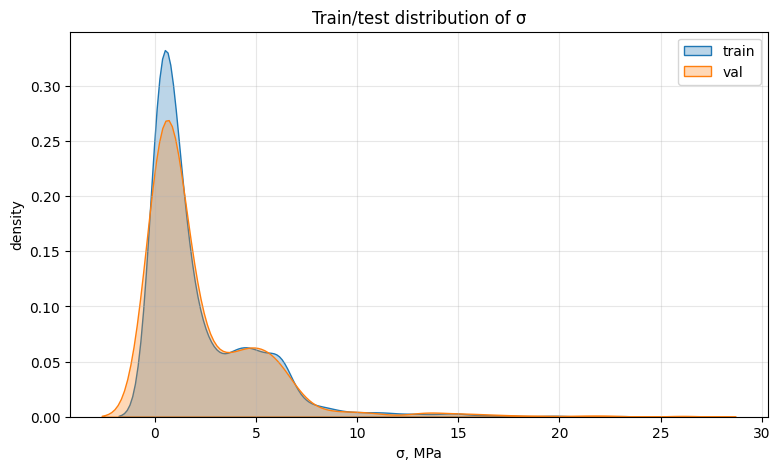

In [1037]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.kdeplot(inverse_log_transform(y_train_opt).ravel(), label="train", fill=True, alpha=0.3)
sns.kdeplot(inverse_log_transform(y_val_opt).ravel(), label="val", fill=True, alpha=0.3)

plt.xlabel("σ, MPa")
plt.ylabel("density")
plt.title("Train/test distribution of σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [1038]:
# import numpy as np
# from sklearn.model_selection import train_test_split


# bins = np.quantile(
#     sigma,
#     q=np.linspace(0, 1, 8)
# )

# # чтобы не было одинаковых границ
# bins = np.unique(bins)

# sigma_bins = np.digitize(sigma, bins[1:-1])

# X_train, X_test, sigma_train, sigma_test = train_test_split(
#     X,
#     sigma,
#     test_size=0.15,
#     random_state=42,
#     stratify=sigma_bins
# )


In [1039]:
# def metrics_by_bins(sigma_true, sigma_pred):
#     bins = [
#         (0, 100),
#         (100, 300),
#         (300, 600),
#         (600, 900),
#         (900, np.inf),
#     ]

#     sigma_true = np.asarray(sigma_true).ravel()
#     sigma_pred = np.asarray(sigma_pred).ravel()

#     for low, high in bins:
#         mask = (sigma_true >= low) & (sigma_true < high)

#         if mask.sum() == 0:
#             continue

#         rmse = mean_squared_error(sigma_true[mask], sigma_pred[mask]) ** 0.5
#         mae = mean_absolute_error(sigma_true[mask], sigma_pred[mask])

#         mape_bin = np.mean(
#             np.abs((sigma_pred[mask] - sigma_true[mask]) / sigma_true[mask])
#         ) * 100

#         print(
#             f"{low:>4} - {high:<6} | "
#             f"n={mask.sum():>4} | "
#             f"RMSE={rmse:>8.2f} | "
#             f"MAE={mae:>8.2f} | "
#             f"MAPE={mape_bin:>8.2f}%"
#         )

# metrics_by_bins(sigma_test, sigma_pred)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# обучаем на log1p(sigma)
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_scaled, y_scaled)

y_pred_scaled_rf = rf.predict(X_test_scaled)

y_pred_log_rf = scaler_y.inverse_transform(
    y_pred_scaled_rf.reshape(-1, 1)
).ravel()

sigma_pred_rf = inverse_log_transform(y_pred_log_rf)
sigma_pred_rf = np.clip(sigma_pred_rf, 0.0, None)

rmse_rf = mean_squared_error(sigma_test, sigma_pred_rf) ** 0.5
r2_rf = r2_score(sigma_test, sigma_pred_rf)
mape_rf = np.mean(np.abs((sigma_pred_rf - sigma_test) / sigma_test)) * 100



/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF RMSE: 128.93 MPa
RF R2  : 0.6838
RF MAPE: 109.41%


In [10]:
print(f"RF RMSE: {rmse_rf:.2f} MPa")
print(f"RF R2  : {r2_rf:.4f}")
print(f"RF MAPE: {mape_rf:.2f}%")
print(f"Min pred σ: {sigma_pred_rf.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_rf.max():.2f} MPa")
print(f"Min true σ: {sigma_test.min():.2f} MPa")
print(f"Max true σ: {sigma_test.max():.2f} MPa")


RF RMSE: 128.93 MPa
RF R2  : 0.6838
RF MAPE: 109.41%
Min pred σ: 49.20 MPa
Max pred σ: 1182.80 MPa
Min true σ: 31.00 MPa
Max true σ: 1279.00 MPa


# optuna

In [1041]:
import optuna
import traceback



def objective(trial):
    input_dim = X_scaled.shape[1]

    # hidden_dim = trial.suggest_int(
    #     "hidden_dim",
    #     2,
    #     30,
    #     log=True
    # )

    activation = trial.suggest_categorical(
        "activation",
        ["tanh", "relu", "silu", "gelu", "elu"]
    )

    lr = trial.suggest_float(
        "lr",
        1e-5,
        3e-2,
        log=True
    )

    alpha_init = trial.suggest_float(
        "alpha_init",
        1e-4,
        10.0,
        log=True
    )

    beta_init = trial.suggest_float(
        "beta_init",
        1.0,
        200.0,
        log=True
    )

    # prior для alpha.
    # alpha_prior_rate больше -> prior меньше тянет alpha вверх,
    # то есть регуляризация в среднем слабее.
    alpha_prior_rate = trial.suggest_float(
        "alpha_prior_rate",
        0.1,
        100.0,
        log=True
    )

    # prior для beta.
    # beta — precision шума.
    # Большая beta = меньше шум.
    beta_prior_rate = trial.suggest_float(
        "beta_prior_rate",
        0.01,
        10.0,
        log=True
    )

    # Можно также перебирать "силу" prior на beta через shape.
    beta_prior_shape = trial.suggest_float(
        "beta_prior_shape",
        0.5,
        10.0,
        log=True
    )

    regularize_bias = trial.suggest_categorical(
    "regularize_bias",
    [True, False]
)

    net = MLPRegressorNet(
        input_dim=input_dim,
        # hidden_dim=hidden_dim,
        activation=activation
    )

    try:
        train_map_brann(
            net=net,
            X_train=X_train_opt,
            y_train=y_train_opt,
            num_steps=4000,
            lr=lr,
            alpha_init=alpha_init,
            beta_init=beta_init,
            alpha_prior_shape=1.0,
            alpha_prior_rate=alpha_prior_rate,
            beta_prior_shape=beta_prior_shape,
            beta_prior_rate=beta_prior_rate,
            regularize_bias=regularize_bias,
            clip_norm=10.0,
            device="cpu",
            seed=42,
        )

        y_pred_val_scaled = predict_map_brann(
            net,
            X_val_opt,
            device="cpu"
        )

        y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()

        sigma_pred_val = inverse_log_transform(y_pred_val)

        sigma_true_val = sigma_val_opt.ravel()

        metrics = regression_metrics_sigma(
            sigma_true_val,
            sigma_pred_val
        )

        params = get_alpha_beta()

        trial.set_user_attr("rmse_abs", metrics["rmse_abs"])
        trial.set_user_attr("mae_abs", metrics["mae_abs"])
        trial.set_user_attr("mape", metrics["mape"])
        trial.set_user_attr("r2", metrics["r2"])
        trial.set_user_attr("final_alpha", params["alpha"])
        trial.set_user_attr("final_beta", params["beta"])
        trial.set_user_attr("sigma_noise_scaled", params["sigma_noise_scaled"])

        # Главная метрика оптимизации
        return metrics["rmse_rel"]


    except Exception as e:
        print("TRIAL FAILED")
        print(e)
        traceback.print_exc()
        return float("inf")



In [1042]:
study = optuna.create_study(
    direction="minimize",
    study_name="map_brann_sigma"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print("Best value:", study.best_value)
print("Best params:")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

print("Best user attrs:")
for k, v in study.best_trial.user_attrs.items():
    print(f"{k}: {v}")


[I 2026-06-03 03:33:46,883] A new study created in memory with name: map_brann_sigma
Best trial: 0. Best value: 0.978044:   2%|▏         | 1/50 [00:21<17:27, 21.38s/it]

[I 2026-06-03 03:34:08,260] Trial 0 finished with value: 0.978043559815279 and parameters: {'activation': 'elu', 'lr': 0.00012045717113097444, 'alpha_init': 1.1522653487320598, 'beta_init': 105.21805128380764, 'alpha_prior_rate': 26.84955152631911, 'beta_prior_rate': 0.07031863049259808, 'beta_prior_shape': 9.347982160798505, 'regularize_bias': True}. Best is trial 0 with value: 0.978043559815279.


Best trial: 1. Best value: 0.961491:   4%|▍         | 2/50 [00:38<14:54, 18.64s/it]

[I 2026-06-03 03:34:24,991] Trial 1 finished with value: 0.9614907402836375 and parameters: {'activation': 'tanh', 'lr': 0.0010686966089000836, 'alpha_init': 0.9034771434195107, 'beta_init': 26.647477127676222, 'alpha_prior_rate': 0.20572609094863148, 'beta_prior_rate': 0.09652920597822656, 'beta_prior_shape': 2.3048446182581253, 'regularize_bias': False}. Best is trial 1 with value: 0.9614907402836375.


Best trial: 1. Best value: 0.961491:   6%|▌         | 3/50 [00:56<14:24, 18.40s/it]

...

[I 2026-06-03 03:49:28,924] Trial 47 finished with value: 0.9333688141550974 and parameters: {'activation': 'relu', 'lr': 0.01353739296034194, 'alpha_init': 0.0003637123137649779, 'beta_init': 1.2358641864121542, 'alpha_prior_rate': 30.01055261429742, 'beta_prior_rate': 0.03813324935292353, 'beta_prior_shape': 1.029268241484598, 'regularize_bias': True}. Best is trial 4 with value: 0.8694357154914928.


Best trial: 4. Best value: 0.869436:  98%|█████████▊| 49/50 [16:02<00:20, 20.04s/it]

[I 2026-06-03 03:49:48,939] Trial 48 finished with value: 0.9533485338624018 and parameters: {'activation': 'relu', 'lr': 0.001432869257810081, 'alpha_init': 0.039006701855930935, 'beta_init': 64.8611011896775, 'alpha_prior_rate': 5.455627078079925, 'beta_prior_rate': 0.38696623536485325, 'beta_prior_shape': 0.7031200915693254, 'regularize_bias': True}. Best is trial 4 with value: 0.8694357154914928.


Best trial: 4. Best value: 0.869436: 100%|██████████| 50/50 [16:22<00:00, 19.65s/it]

[I 2026-06-03 03:50:09,153] Trial 49 finished with value: 0.9925632421550991 and parameters: {'activation': 'silu', 'lr': 0.00853803397478418, 'alpha_init': 0.00812538203396062, 'beta_init': 11.22788197976184, 'alpha_prior_rate': 2.5075746953657294, 'beta_prior_rate': 0.012346682632117488, 'beta_prior_shape': 0.7953278152643685, 'regularize_bias': True}. Best is trial 4 with value: 0.8694357154914928.
Best value: 0.8694357154914928
Best params:
activation: relu
lr: 0.010599676851582803
alpha_init: 0.00011791187684357717
beta_init: 50.876733656730764
alpha_prior_rate: 3.4153795338077937
beta_prior_rate: 0.043251760959187306
beta_prior_shape: 1.0741876904217318
regularize_bias: True
Best user attrs:
rmse_abs: 139.61247925962064
mae_abs: 94.03662858821127
mape: 39.41544060278406
r2: 0.6908341962029525
final_alpha: 10.632217407226562
final_beta: 8.283763885498047
sigma_noise_scaled: 0.3474450623868873


Best value: 0.854725547408852
Best params:
hidden_dim: 11
activation: gelu
lr: 0.026053779483632567
alpha_init: 0.0009531055978600405
beta_init: 1.1781615420752112
alpha_prior_rate: 2.9549589377332244
beta_prior_rate: 0.03822059220992772
beta_prior_shape: 0.5580949970329177
Best user attrs:
rmse_abs: 145.0190057574377
mae_abs: 99.6212582665093
mape: 40.53959317888554
r2: 0.6664255188259909
final_alpha: 13.614280700683594
final_beta: 7.910255432128906
sigma_noise_scaled: 0.3555533264955847

In [1043]:
best_params = study.best_params


best_net = MLPRegressorNet(
    input_dim=X_scaled.shape[1],
    hidden_dim=best_params["hidden_dim"],
    activation=best_params["activation"]
)

train_map_brann(
    net=best_net,
    X_train=X_train_opt,
    y_train=y_train_opt,
    num_steps=5000,
    lr=best_params["lr"],
    alpha_init=best_params["alpha_init"],
    beta_init=best_params["beta_init"],
    alpha_prior_shape=1.0,
    alpha_prior_rate=best_params["alpha_prior_rate"],
    beta_prior_shape=best_params["beta_prior_shape"],
    beta_prior_rate=best_params["beta_prior_rate"],
    regularize_bias=best_params["regularize_bias"],
    clip_norm=10.0,
    device="cpu",
    seed=42,
)


KeyError: 'hidden_dim'

In [ ]:
y_pred_val_scaled = predict_map_brann(
    best_net,
    X_val_opt,
    device="cpu"
)

y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()

sigma_pred_val = inverse_log_transform(y_pred_val)

sigma_true_val = sigma_val_opt.ravel()

metrics = regression_metrics_sigma(
    sigma_true_val,
    sigma_pred_val
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("Alpha/beta:")
print(get_alpha_beta())

print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")


Final validation metrics:
rmse_abs: 136.8189
mae_abs: 95.6059
rmse_rel: 1.0795
mape: 45.2828
r2: 0.7031
Alpha/beta:
{'alpha': 10.523421287536621, 'beta': 7.192573547363281, 'sigma_noise_scaled': 0.37287034474806796}
Min pred σ: 58.08 MPa
Max pred σ: 1931.68 MPa
Min true σ: 5.00 MPa
Max true σ: 1550.00 MPa


In [ ]:
y_pred_test_scaled = predict_map_brann(
    best_net,
    X_test,
    device="cpu"
)

y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()

sigma_pred_test = inverse_log_transform(y_pred_test)

sigma_true_test = sigma_test.ravel()

metrics = regression_metrics_sigma(
    sigma_true_test,
    sigma_pred_test
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("Alpha/beta:")
print(get_alpha_beta())

print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")

Final validation metrics:
rmse_abs: 284.6935
mae_abs: 206.2674
rmse_rel: 0.7584
mape: 56.2988
r2: -0.5418
Alpha/beta:
{'alpha': 10.523421287536621, 'beta': 7.192573547363281, 'sigma_noise_scaled': 0.37287034474806796}
Min pred σ: 58.08 MPa
Max pred σ: 1931.68 MPa
Min true σ: 5.00 MPa
Max true σ: 1550.00 MPa
